In [4]:
import seaborn as sns
import pandas as pd

df = sns.load_dataset("titanic")
df.to_csv("titanic.csv", index=False)
df = pd.read_csv("titanic.csv")
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [5]:
print(df.info())
print('shape',df.shape)
print(df.describe())

# Null percentages in each column

print("\nNull percentages in each column:\n")
print("=="*25)
print(f"{'Column Names':<15} {'Missing Percentage':>20}")
print("=="*25)

for x in df.columns.to_list():
   y = ((df[x].isnull().sum())/len(df))*100
   print(f"{x:<15}{y:>20.2f}")

# 1. Fill missing age values with the mean age because it has 19.87 percentage of missing value and mean imputation can be done
# and it effects the data analysis witht the null rows removal from dataset

df['age'] = df['age'].fillna(df['age'].mean())

# 2. Drop deck because it has ~77% missing values and don't contribute in data anlysis
df = df.drop(columns=['deck'])

# 3. Remove rows with missing embarkation information because these columns has missing values less than one percent
# and don't effect the data analysis with the rows removal
df = df.dropna(subset=['embarked', 'embark_town'])



<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB
None
shape (891, 15)
         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.00

Plotting a histogram and a box plot for both age and fare

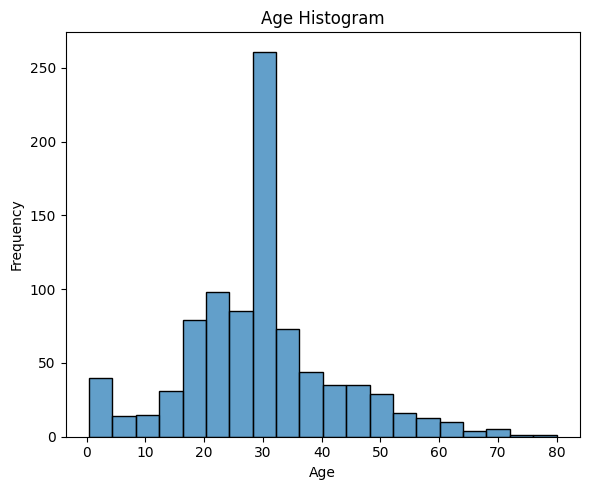

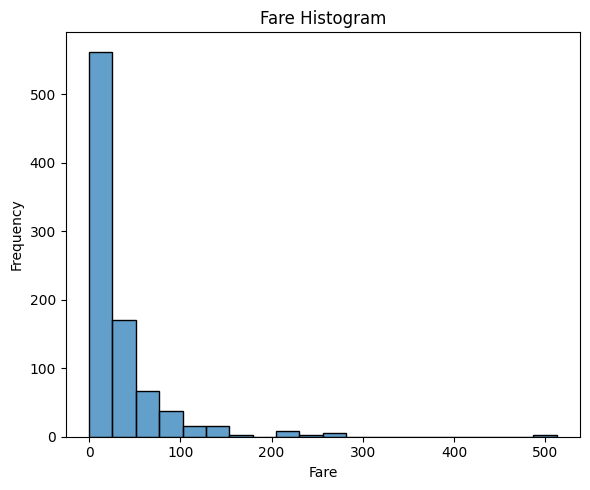

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("charts", exist_ok=True)

# 1. Age Histogram

plt.figure(figsize=(6, 5))

sns.histplot(data=df,x="age",bins=20,kde=False,edgecolor="black",alpha=0.7)

plt.title("Age Histogram")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.tight_layout()

# Save Age plot
plt.savefig("charts/age_histogram.png",dpi=300,bbox_inches="tight")

plt.show()
plt.close()

# 2. Fare Histogram

plt.figure(figsize=(6, 5))

sns.histplot(data=df,x="fare",bins=20,kde=False,edgecolor="black",alpha=0.7)

plt.title("Fare Histogram")
plt.xlabel("Fare")
plt.ylabel("Frequency")

plt.tight_layout()

# Save Fare plot
plt.savefig("charts/fare_histogram.png",dpi=300,bbox_inches="tight")

plt.show()
plt.close()


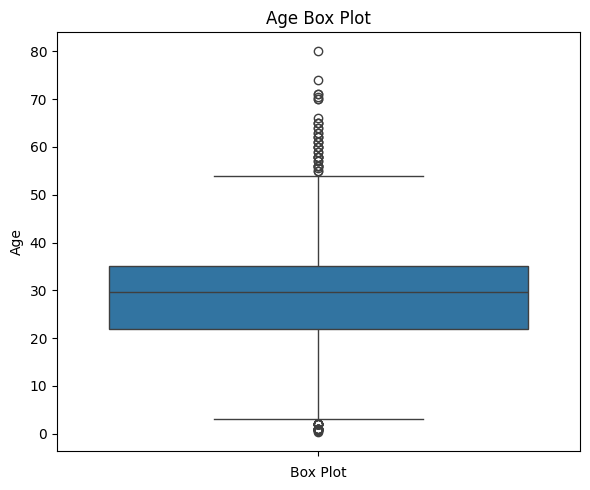

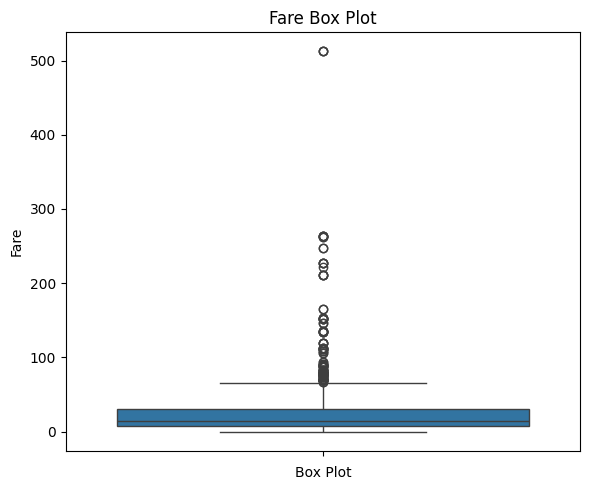

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Age Box Plot

plt.figure(figsize=(6, 5))

sns.boxplot(data=df,y="age")

plt.title("Age Box Plot")
plt.xlabel("Box Plot")
plt.ylabel("Age")

plt.tight_layout()

# Save Age box plot
plt.savefig("charts/age_boxplot.png",dpi=300,bbox_inches="tight")

plt.show()
plt.close()


# 2. Fare Box Plot

plt.figure(figsize=(6, 5))

sns.boxplot(data=df,y="fare")

plt.title("Fare Box Plot")
plt.xlabel("Box Plot")
plt.ylabel("Fare")

plt.tight_layout()

# Save Fare box plot
plt.savefig("charts/fare_boxplot.png",dpi=300,bbox_inches="tight")

plt.show()
plt.close()


In [8]:
# no.of outliers calculation for Age and fare column

def outliers(column) :
   Q1 = df[column].quantile(0.25)
   Q3 = df[column].quantile(0.75)

   IQR = Q3-Q1
   Lower_boundary = Q1-1.5*IQR
   Upper_boundry = Q3+1.5*IQR

   outliers = [ x for x in df[column].to_list() if (x < Lower_boundary) or (x > Upper_boundry)]
   return len(outliers)

print(f"No.of outliers in Age column is : {outliers('age')}")
print(f"No.of outliers in Fare column is : {outliers('fare')}")

# Fare data distribution

fare_mean = round(df['fare'].mean(),2)
fare_median = round(df['fare'].median(),2)
fare_mode = round(df['fare'].mode()[0],2)
print(f" fare_mean : {fare_mean}\n fare_median : {fare_median}\n fare_mode : {fare_mode}")

if fare_mode == fare_mean == fare_median:
  print("fare column data is symmetric because Mode = Mean= Median")
elif fare_mode > fare_median > fare_mean :
  print(f" fare column data is Left-Skewed because Mode > Median > Mean \n {fare_mode}>{fare_median}>{fare_mean}")
elif fare_mode < fare_median < fare_mean :
  print(f"fare column data is Right-Skewed because Mode < Median < Mean \n {fare_mode}<{fare_median}<{fare_mean}")
else: 
  print("distribution shape is mixed/ambiguous")


No.of outliers in Age column is : 65
No.of outliers in Fare column is : 114
 fare_mean : 32.1
 fare_median : 14.45
 fare_mode : 8.05
fare column data is Right-Skewed because Mode < Median < Mean 
 8.05<14.45<32.1


In [9]:
# Survival rate by sex
print("\nSurvival rate by sex:\n")
female_mask = df['sex'] == 'female'

female_survival_rate = (
    (female_mask & (df['survived'] == 1)).sum()
    / female_mask.sum()
) * 100

print(f"Female survival rate: {female_survival_rate:.2f}%")


male_mask = df['sex'] == 'male'

male_survival_rate = (
    (male_mask & (df['survived'] == 1)).sum()
    / male_mask.sum()
) * 100

print(f"Male survival rate: {male_survival_rate:.2f}%")

# Survival rate by pclass
print("\nSurvival rate by pclass:\n")
for pclass in df['pclass'].unique():

    class_mask = df['pclass'] == pclass

    survival_rate = (
        (class_mask & (df['survived'] == 1)).sum()
        / class_mask.sum()
    ) * 100

    print(f"Pclass {pclass} survival rate: {survival_rate:.2f}%")


# sex AND pclass together
print("\nSex and pclass together:\n")
for sex in df['sex'].unique():

    for pclass in df['pclass'].unique():

        group_mask = (
            (df['sex'] == sex) &
            (df['pclass'] == pclass)
        )

        survival_rate = (
            (group_mask & (df['survived'] == 1)).sum()
            / group_mask.sum()
        ) * 100

        print(
            f"{sex}, Pclass {pclass} survival rate: "
            f"{survival_rate:.2f}%"
        )


Survival rate by sex:

Female survival rate: 74.04%
Male survival rate: 18.89%

Survival rate by pclass:

Pclass 3 survival rate: 24.24%
Pclass 1 survival rate: 62.62%
Pclass 2 survival rate: 47.28%

Sex and pclass together:

male, Pclass 3 survival rate: 13.54%
male, Pclass 1 survival rate: 36.89%
male, Pclass 2 survival rate: 15.74%
female, Pclass 3 survival rate: 50.00%
female, Pclass 1 survival rate: 96.74%
female, Pclass 2 survival rate: 92.11%


Heatmap

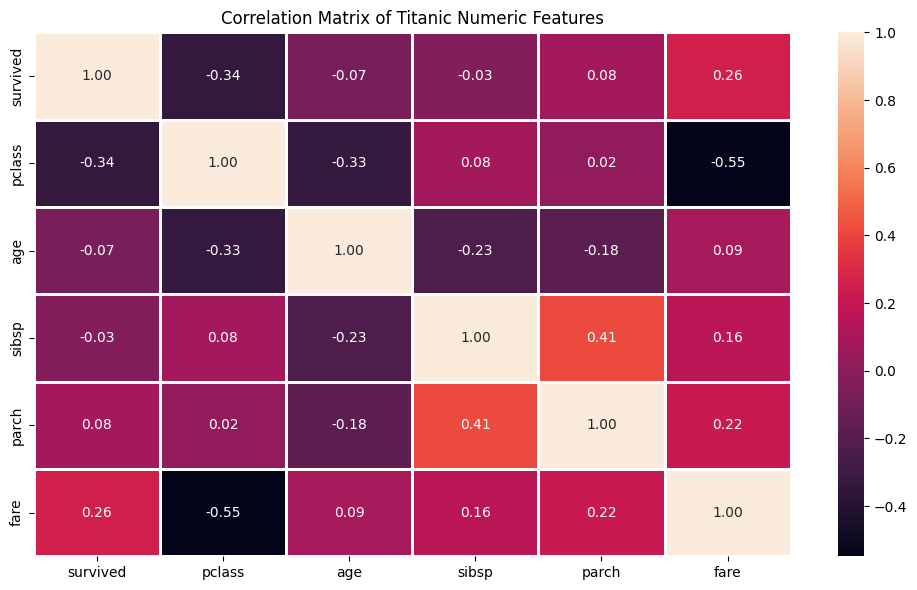

Two strongest correlations:
pclass  fare    -0.548193
sibsp   parch    0.414542
dtype: float64
1. Pclass and Fare: These variables have the strongest negative correlation (around -0.55). This indicates that passengers in higher-numbered classes generally paid lower fares, while first-class passengers tended to have higher fares.

2. Sibsp and Parch: These variables have the second-strongest positive correlation (around +0.41). This indicates that passengers who had more siblings/spouses aboard also tended, to some extent, to have more parents/children aboard.


In [10]:
import numpy as np

fig,ax = plt.subplots(figsize=(10,6))
correlation_matrix = df[['survived','pclass', 'age', 'sibsp', 'parch','fare']].corr()
sns.heatmap(correlation_matrix,annot = True,linewidths=1,fmt=".2f")
plt.title("Correlation Matrix of Titanic Numeric Features")
plt.tight_layout()
plt.savefig("charts/correlation_heatmap.png",dpi=300,bbox_inches="tight")
plt.show()



# Keep only the upper triangle
upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

# Rank by absolute correlation
top_two = (
    upper_triangle
    .stack()
    .sort_values(key=abs, ascending=False)
    .head(2)
)

print("Two strongest correlations:")
print(top_two)

print('''1. Pclass and Fare: These variables have the strongest negative correlation (around -0.55). This indicates that passengers in higher-numbered classes generally paid lower fares, while first-class passengers tended to have higher fares.

2. Sibsp and Parch: These variables have the second-strongest positive correlation (around +0.41). This indicates that passengers who had more siblings/spouses aboard also tended, to some extent, to have more parents/children aboard.''')

Survival rates

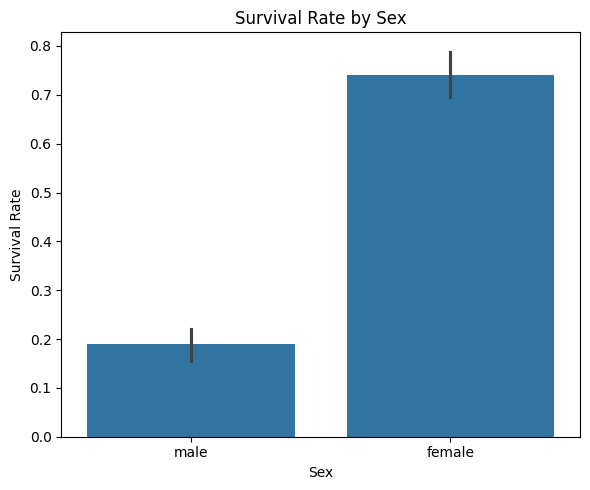

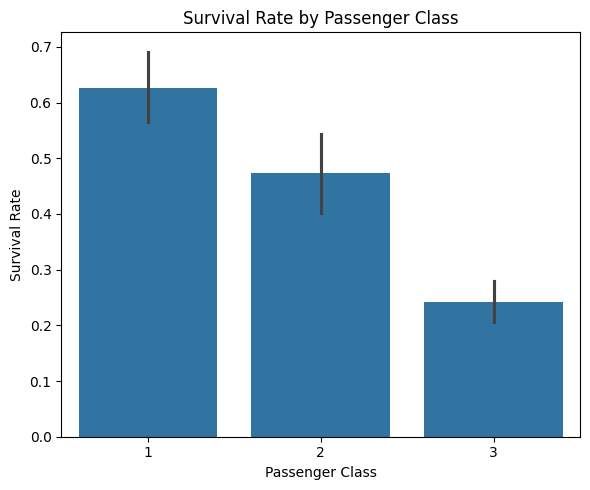

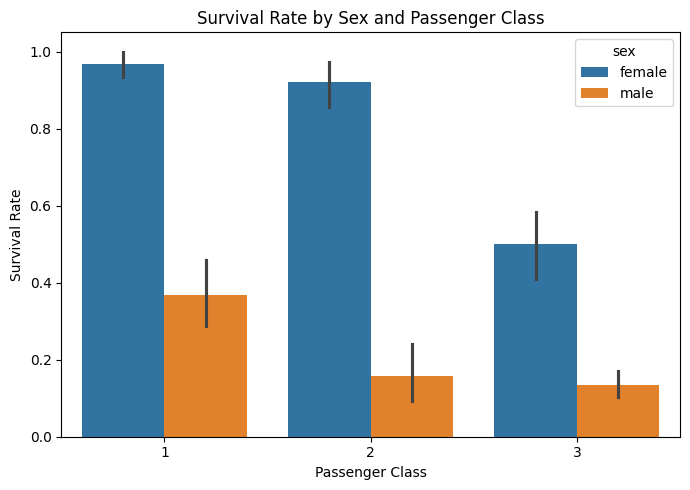

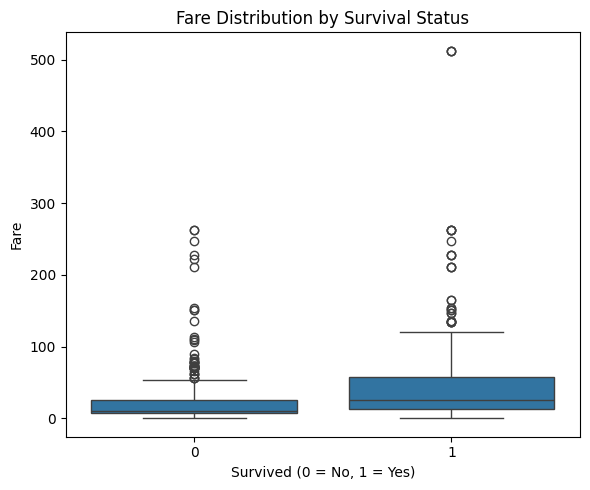

In [ ]:

# Chart 1 — Survival Rate by Sex

plt.figure(figsize=(6, 5))

sns.barplot(data=df, x='sex', y='survived')

plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")

plt.tight_layout()
plt.savefig("charts/survival_rate_by_sex.png", dpi=300, bbox_inches="tight")
plt.show()


# Chart 2 — Survival Rate by Passenger Class

plt.figure(figsize=(6, 5))

sns.barplot(data=df, x='pclass', y='survived')

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.tight_layout()
plt.savefig("charts/survival_rate_by_passenger_class.png", dpi=300, bbox_inches="tight")
plt.show()


# Chart 3 — Survival Rate by Sex and Passenger Class

plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x='pclass',
    y='survived',
    hue='sex'
)

plt.title("Survival Rate by Sex and Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.tight_layout()
plt.savefig("charts/survival_rate_by_sex_and_class.png", dpi=300, bbox_inches="tight")
plt.show()


# Chart 4 — Fare Distribution by Survival Status

plt.figure(figsize=(6, 5))

sns.boxplot(
    data=df,
    x='survived',
    y='fare'
)

plt.title("Fare Distribution by Survival Status")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Fare")

plt.tight_layout()
plt.savefig("charts/fare_distribution_by_survival.png", dpi=300, bbox_inches="tight")
plt.show()

# Multivariate Data Story

1. Survival Rate by Sex
Female passengers had a substantially higher survival rate than male passengers. Approximately three-quarters of female passengers survived, compared with less than one-fifth of male passengers. This shows that sex was strongly associated with survival outcomes on the Titanic.

2. Survival Rate by Passenger Class
Survival rates decreased substantially as passenger class increased from first to third class. First-class passengers had the highest survival rate, while third-class passengers had the lowest. This suggests that passenger class was an important factor associated with survival.

3. Survival Rate by Sex and Passenger Class
Combining sex and passenger class reveals that survival was influenced by both factors rather than by either factor alone. Female passengers generally had much higher survival rates across passenger classes, while male passengers—especially those in third class—had very low survival rates. This interaction provides stronger evidence for the story that both gender and socioeconomic position were associated with survival.

4. Fare Distribution by Survival Status
Survivors generally had higher fare values than passengers who did not survive, although there is substantial overlap between the two distributions. This is consistent with the earlier finding that higher passenger classes, which tended to have higher fares, were associated with better survival rates. Therefore, fare appears to provide another indication of the socioeconomic differences associated with survival.

Overall Conclusion
Overall data story: Survival on the Titanic was strongly associated with sex and passenger class. Female passengers had substantially higher survival rates than male passengers, while first-class passengers survived at higher rates than second- and third-class passengers. When sex and passenger class were examined together, the differences became even clearer, with male third-class passengers showing particularly low survival. Fare distributions further support the socioeconomic pattern, as survivors generally paid higher fares, although fare and survival distributions overlap and correlation should not be interpreted as causation.

In [12]:
df['age_z'] = (df['age']-df['age'].mean())/(df['age'].std())
df['fare_z'] = (df['fare']-df['fare'].mean())/(df['fare'].std())

print("Before standardization:")
print(
    df[['age', 'fare']].agg(['mean', 'std']).round(2)
)

print("\nAfter standardization:")
print(
    df[['age_z', 'fare_z']].agg(['mean', 'std']).round(2)
)


Before standardization:
        age  fare
mean  29.65  32.1
std   12.97  49.7

After standardization:
      age_z  fare_z
mean    0.0     0.0
std     1.0     1.0
